# Artificial Intelligence and Machine Learning: Worksheet 5
Prepared by: Aayush Khatiwada  
Group: L6CG13

# Implement an End to End CNN Model for Image Classification Task.

## Task 1: Data Understanding and Visualization:

### Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


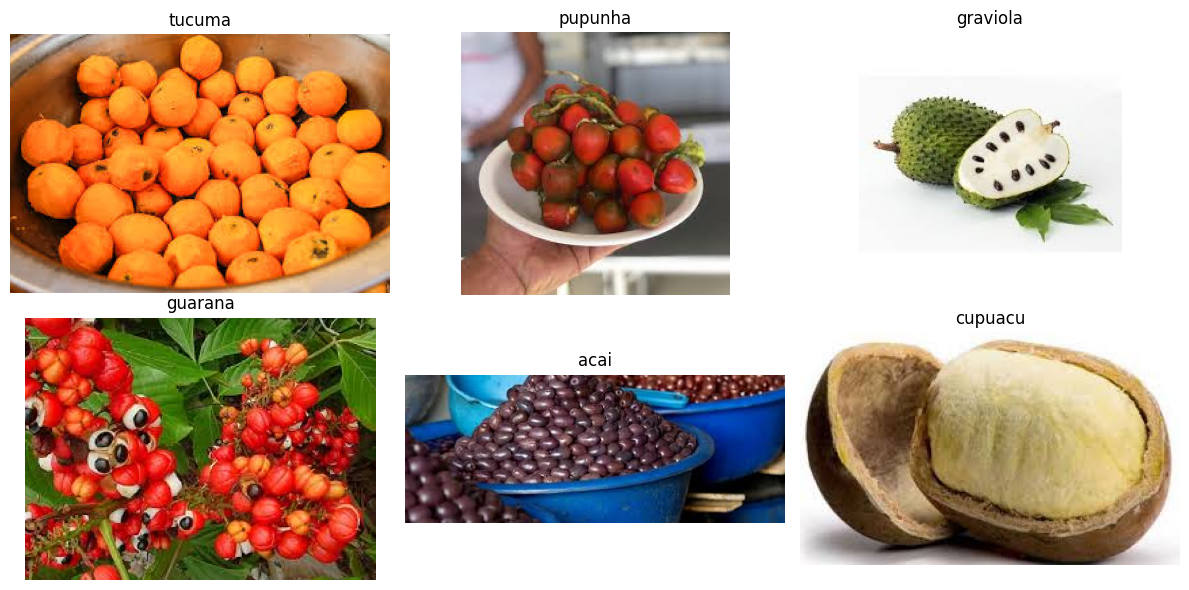

In [2]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = '/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/train'
test_dir = '/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/test'

classes = os.listdir(train_dir)

plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)
    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    img = mpimg.imread(img_path)
    plt.subplot(2, (len(classes) + 1) // 2, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

Q: What did you observe?  
Ans: From above, we can observe that there are six classes of fruits.

### Check for Corrupted Image.

In [3]:
from PIL import Image

corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError) as e:
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")
            corrupted_images.append(img_path)

if not corrupted_images:
    print("No corrupted images found.")

No corrupted images found.


## Task 2: Loading and Preprocessing Image Data in keras:

In [4]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test Dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


## Task 3 - Implement a CNN with:

In [5]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

### Convolutional Architecture and Fully Connected Network Architecture

In [6]:
model = Sequential([
    # Convolutional Layer 1
    Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully Connected Network
    Flatten(),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile the Model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Task 5: Train the Model

In [8]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

epochs = 250
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.1549 - loss: 1.9355

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 458ms/step - accuracy: 0.1389 - loss: 1.9445 - val_accuracy: 0.1111 - val_loss: 1.7527
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.3545 - loss: 1.7090

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 354ms/step - accuracy: 0.3611 - loss: 1.6990 - val_accuracy: 0.2778 - val_loss: 1.6734
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.5191 - loss: 1.4443

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 387ms/step - accuracy: 0.5278 - loss: 1.4104 - val_accuracy: 0.6667 - val_loss: 1.1694
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.6250 - loss: 1.0339 - val_accuracy: 0.5556 - val_loss: 1.3128
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.7153 - loss: 0.7380

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 610ms/step - accuracy: 0.7222 - loss: 0.7391 - val_accuracy: 0.7778 - val_loss: 0.7952
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9431 - loss: 0.4498

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 485ms/step - accuracy: 0.9444 - loss: 0.3961 - val_accuracy: 0.8333 - val_loss: 0.8573
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9403 - loss: 0.2837

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 386ms/step - accuracy: 0.9306 - loss: 0.2814 - val_accuracy: 0.9444 - val_loss: 0.2820
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 512ms/step - accuracy: 1.0000 - loss: 0.1176 - val_accuracy: 0.8333 - val_loss: 0.6583
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 610ms/step - accuracy: 0.9861 - loss: 0.1006 - val_accuracy: 0.8333 - val_loss: 0.5708
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 464ms/step - accuracy: 0.9861 - loss: 0.0719 - val_accuracy: 0.8889 - val_loss: 0.2104
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 361ms/step - accuracy: 1.0000 - loss: 0.0399 - val_accuracy: 0.8333 - val_loss: 0.2811
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 0.8333 - val_loss: 0.5607
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 342ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.8333 - val_loss: 0.6593
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 380ms/step - accuracy: 1.0000 - loss: 0.0138 - val_accuracy: 0.8333 - val_loss

## Task 6: Evaluate the Model

In [9]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.7333 - loss: 0.6632
Test Accuracy: 73.33%
Test Loss: 0.6632


### Graphs showing the training and validation loss and accuracy.

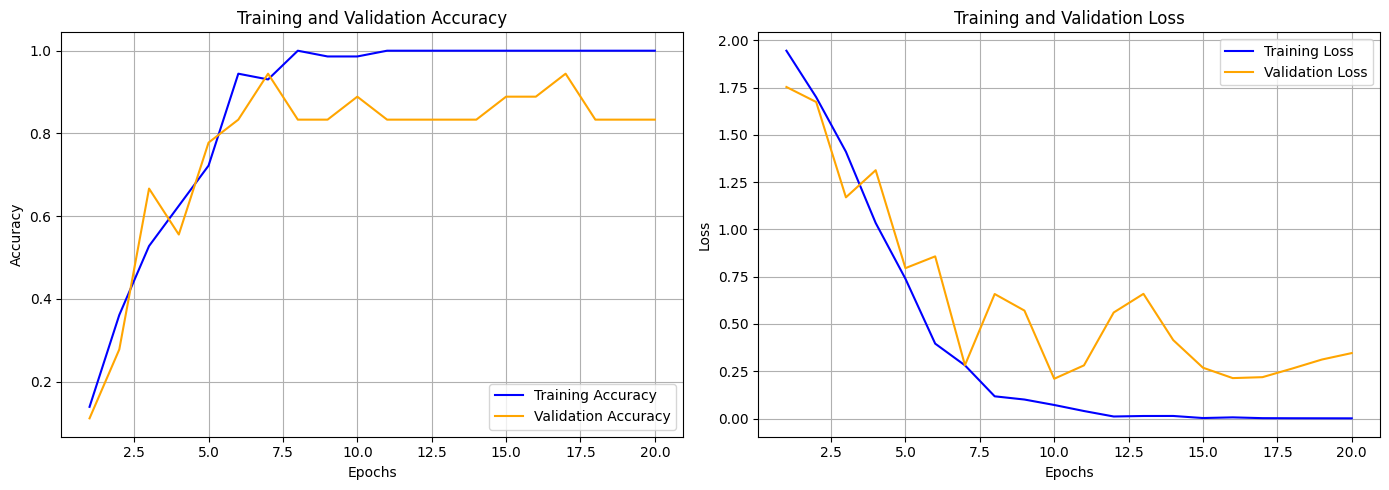

In [10]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)


plt.tight_layout()
plt.show()

## Task 7: Save and Load the Model

In [11]:
from keras.models import load_model

model.save('/content/drive/MyDrive/AI and ML/Week 5/final_model.h5')
print("Model saved successfully.")

loaded_model = load_model('/content/drive/MyDrive/AI and ML/Week 5/final_model.h5')
print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


### Re-evaluating its performance on test set

In [12]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print(f"Loaded Model Accuracy: {loaded_accuracy*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.7333 - loss: 0.6632
Loaded Model Accuracy: 73.33%


## Task 8: Predictions and Classification Report

### Making Predictions

In [13]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred_probs = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.60      0.75         5
           1       0.75      0.60      0.67         5
           2       0.56      1.00      0.71         5
           3       0.62      1.00      0.77         5
           4       1.00      0.80      0.89         5
           5       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.82      0.73      0.73        30
weighted avg       0.82      0.73      0.73        30

